In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier,RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score,recall_score,precision_score
from sklearn.preprocessing import LabelEncoder,StandardScaler

In [2]:
data=pd.read_csv("Bank_Transaction_Fraud_Detection.csv")
data.head(5)

,Customer_ID,Customer_Name,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_ID,Transaction_Date,...,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Currency,Customer_Contact,Transaction_Description,Customer_Email
0,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e,Osha Tella,Male,60,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,4fa3208f-9e23-42dc-b330-844829d0c12c,23-01-2025,...,Restaurant,74557.27,Voice Assistant,"Thiruvananthapuram, Kerala",POS,0,INR,+9198579XXXXXX,Bitcoin transaction,oshaXXXXX@XXXXX.com
1,7c14ad51-781a-4db9-b7bd-67439c175262,Hredhaan Khosla,Female,51,Maharashtra,Nashik,Nashik Branch,Business,c9de0c06-2c4c-40a9-97ed-3c7b8f97c79c,11/1/2025,...,Restaurant,74622.66,POS Mobile Device,"Nashik, Maharashtra",Desktop,0,INR,+9191074XXXXXX,Grocery delivery,hredhaanXXXX@XXXXXX.com
2,3a73a0e5-d4da-45aa-85f3-528413900a35,Ekani Nazareth,Male,20,Bihar,Bhagalpur,Bhagalpur Branch,Savings,e41c55f9-c016-4ff3-872b-cae72467c75c,25-01-2025,...,Groceries,66817.99,ATM,"Bhagalpur, Bihar",Desktop,0,INR,+9197745XXXXXX,Mutual fund investment,ekaniXXX@XXXXXX.com
3,7902f4ef-9050-4a79-857d-9c2ea3181940,Yamini Ramachandran,Female,57,Tamil Nadu,Chennai,Chennai Branch,Business,7f7ee11b-ff2c-45a3-802a-49bc47c02ecb,19-01-2025,...,Entertainment,58177.08,POS Mobile App,"Chennai, Tamil Nadu",Mobile,0,INR,+9195889XXXXXX,Food delivery,yaminiXXXXX@XXXXXXX.com
4,3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9,Kritika Rege,Female,43,Punjab,Amritsar,Amritsar Branch,Savings,f8e6ac6f-81a1-4985-bf12-f60967d852ef,30-01-2025,...,Entertainment,16108.56,Virtual Card,"Amritsar, Punjab",Mobile,0,INR,+9195316XXXXXX,Debt repayment,kritikaXXXX@XXXXXX.com


In [3]:
print(data.columns.tolist())


['Customer_ID', 'Customer_Name', 'Gender', 'Age', 'State', 'City', 'Bank_Branch', 'Account_Type', 'Transaction_ID', 'Transaction_Date', 'Transaction_Time', 'Transaction_Amount', 'Merchant_ID', 'Transaction_Type', 'Merchant_Category', 'Account_Balance', 'Transaction_Device', 'Transaction_Location', 'Device_Type', 'Is_Fraud', 'Transaction_Currency', 'Customer_Contact', 'Transaction_Description', 'Customer_Email']


In [4]:
data=data.drop(["Customer_ID","Customer_Name","Transaction_ID","Customer_Contact","Customer_Email","Merchant_ID","Transaction_Currency"],axis=1)


In [5]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Gender                   200000 non-null  object 
 1   Age                      200000 non-null  int64  
 2   State                    200000 non-null  object 
 3   City                     200000 non-null  object 
 4   Bank_Branch              200000 non-null  object 
 5   Account_Type             200000 non-null  object 
 6   Transaction_Date         200000 non-null  object 
 7   Transaction_Time         200000 non-null  object 
 8   Transaction_Amount       200000 non-null  float64
 9   Transaction_Type         200000 non-null  object 
 10  Merchant_Category        200000 non-null  object 
 11  Account_Balance          200000 non-null  float64
 12  Transaction_Device       200000 non-null  object 
 13  Transaction_Location     200000 non-null  object 
 14  Devi

In [6]:
data.describe()


,Age,Transaction_Amount,Account_Balance,Is_Fraud
count,200000.000000,200000.000000,200000.000000,200000.000000
mean,44.015110,49538.015554,52437.988784,0.050440
std,15.288774,28551.874004,27399.507128,0.218852
min,18.000000,10.290000,5000.820000,0.000000
25%,31.000000,24851.345000,28742.395000,0.000000
50%,44.000000,49502.440000,52372.555000,0.000000
75%,57.000000,74314.625000,76147.670000,0.000000
max,70.000000,98999.980000,99999.950000,1.000000


In [7]:
data.isnull().sum()

Gender                     0
Age                        0
State                      0
City                       0
Bank_Branch                0
Account_Type               0
Transaction_Date           0
Transaction_Time           0
Transaction_Amount         0
Transaction_Type           0
Merchant_Category          0
Account_Balance            0
Transaction_Device         0
Transaction_Location       0
Device_Type                0
Is_Fraud                   0
Transaction_Description    0
dtype: int64

In [8]:
data.duplicated().sum()

np.int64(0)

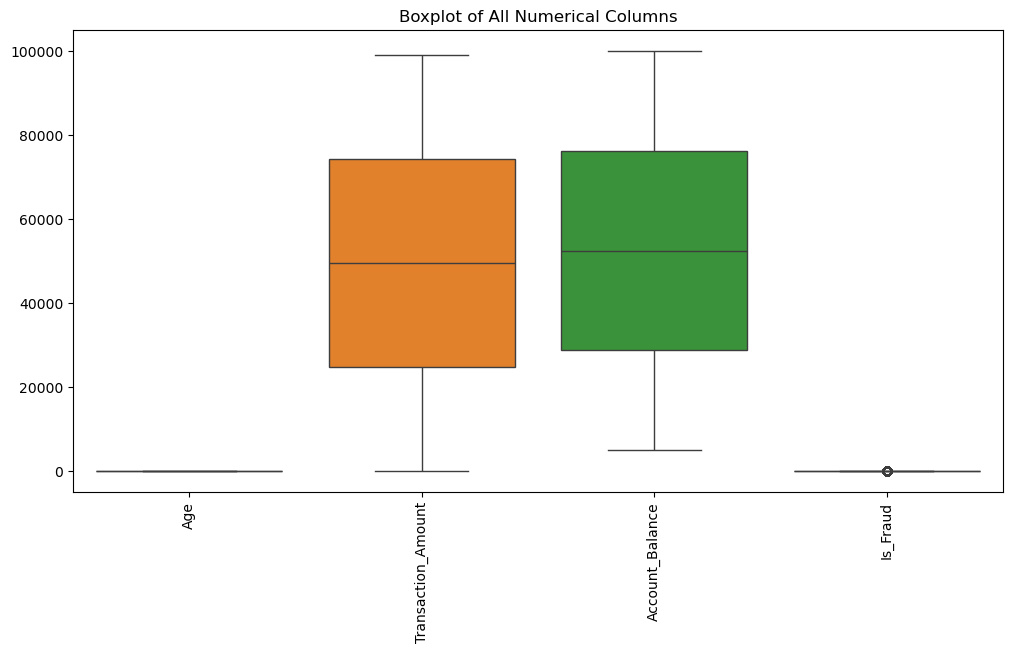

In [9]:
numerical_cols = data.select_dtypes(include=['number'])
plt.figure(figsize=(12, 6))
sns.boxplot(data=numerical_cols)
plt.xticks(rotation=90) 
plt.title("Boxplot of All Numerical Columns")
plt.show()

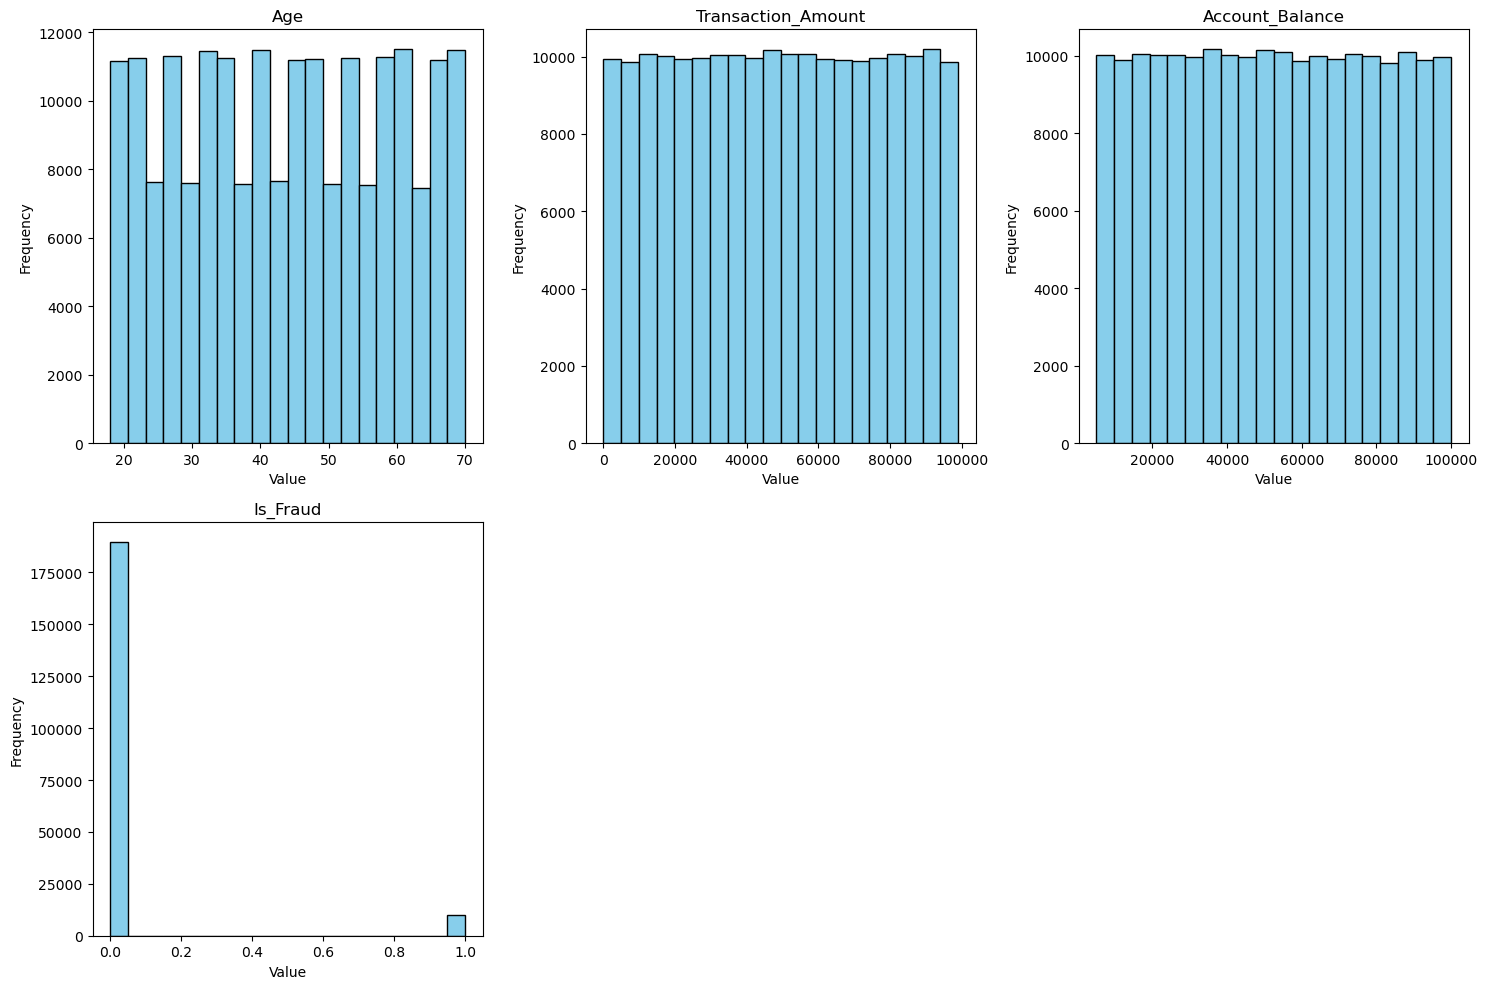

In [10]:
numerical_cols = data.select_dtypes(include=['number'])

num_cols = len(numerical_cols.columns)
fig, axes = plt.subplots(nrows=num_cols // 3 + 1, ncols=3, figsize=(15, num_cols * 2.5))
axes = axes.flatten() 
for i, col in enumerate(numerical_cols.columns):
    axes[i].hist(data[col], bins=20, color='skyblue', edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

for i in range(num_cols, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [11]:
#converting categorical data into numbers using label encoding
categorical_cols = data.select_dtypes(include=['object']).columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le  

In [12]:
data.head(5)

,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_Date,Transaction_Time,Transaction_Amount,Transaction_Type,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Description
0,1,60,15,127,127,2,15,22978,32415.45,3,5,74557.27,17,129,3,0,9
1,0,51,18,100,100,0,2,26785,43622.60,0,5,74622.66,9,102,1,0,65
2,1,20,4,13,13,2,17,55686,63062.56,0,3,66817.99,0,13,1,0,102
3,0,57,28,22,22,0,10,11197,14000.72,2,2,58177.08,8,24,2,0,51
4,0,43,25,7,7,2,23,30879,18335.16,3,2,16108.56,16,7,2,0,37


<Axes: >

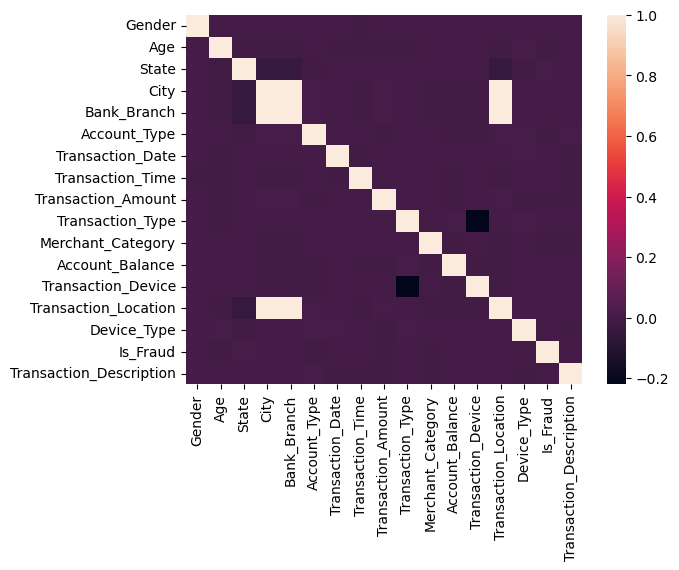

In [13]:
sns.heatmap(data.corr())

In [14]:
data.corr()

,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_Date,Transaction_Time,Transaction_Amount,Transaction_Type,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Description
Gender,1.000000,0.001692,0.002899,-0.000299,-0.000299,0.001260,-0.000180,-0.003121,0.001468,0.001339,0.002233,-0.000392,0.002109,-0.000261,-0.000534,0.000649,-0.000869
Age,0.001692,1.000000,-0.004638,-0.002284,-0.002284,-0.000281,-0.001610,-0.001257,-0.003087,-0.001291,-0.000381,0.000269,0.002429,-0.002291,0.004997,-0.001517,-0.000346
State,0.002899,-0.004638,1.000000,-0.046278,-0.046278,-0.002314,0.003639,-0.000499,0.002480,-0.000130,0.001078,0.000136,0.001103,-0.044936,-0.001835,0.005716,0.001027
City,-0.000299,-0.002284,-0.046278,1.000000,1.000000,0.007245,0.001036,-0.002306,0.005674,0.000101,-0.001047,-0.002628,-0.001441,0.999910,-0.000052,0.002800,0.001547
Bank_Branch,-0.000299,-0.002284,-0.046278,1.000000,1.000000,0.007245,0.001036,-0.002306,0.005674,0.000101,-0.001047,-0.002628,-0.001441,0.999910,-0.000052,0.002800,0.001547
Account_Type,0.001260,-0.000281,-0.002314,0.007245,0.007245,1.000000,0.001415,-0.000953,-0.004737,0.001876,0.000169,-0.001506,-0.003000,0.007216,0.004613,-0.002592,0.005007
Transaction_Date,-0.000180,-0.001610,0.003639,0.001036,0.001036,0.001415,1.000000,-0.001787,-0.000137,0.002434,0.003350,0.002730,0.001003,0.001035,0.004414,0.001150,-0.001107
Transaction_Time,-0.003121,-0.001257,-0.000499,-0.002306,-0.002306,-0.000953,-0.001787,1.000000,0.000539,0.000725,0.001264,-0.003551,0.002092,-0.002267,-0.000324,0.000746,-0.001902
Transaction_Amount,0.001468,-0.003087,0.002480,0.005674,0.005674,-0.004737,-0.000137,0.000539,1.000000,0.001788,-0.000628,-0.001735,-0.000665,0.005656,-0.001315,-0.002100,-0.003523
Transaction_Type,0.001339,-0.001291,-0.000130,0.000101,0.000101,0.001876,0.002434,0.000725,0.001788,1.000000,0.002913,0.003874,-0.220293,0.000075,0.005041,0.000630,0.000065


In [15]:
models={
    "Random Forest Classifier":RandomForestClassifier(),
    "Decision Tree Classifier":DecisionTreeClassifier(),
    "Ada Boost Classifier":AdaBoostClassifier(),
    "Logistic Regression":LogisticRegression(),
    "Gradiant Boosting Classifier":GradientBoostingClassifier(),
    "Naive Bayes Classifier":GaussianNB()
}

In [16]:
x=data.drop(["Is_Fraud"],axis=1)
y=data["Is_Fraud"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)


In [17]:
numerical_cols = x_train.select_dtypes(include=['number']).columns

mask = pd.Series(True, index=x_train.index)

for col in numerical_cols:
    Q1 = x_train[col].quantile(0.25)
    Q3 = x_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask &= (x_train[col] >= lower) & (x_train[col] <= upper)

x_train = x_train[mask]
y_train = y_train[mask]


In [18]:
ss=StandardScaler()
x_train=ss.fit_transform(x_train)
x_test=ss.transform(x_test)

In [19]:
metrics = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall':[]
}
for name,model in models.items():
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall=recall_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    metrics['Model'].append(name)
    metrics['Accuracy'].append(acc * 100)
    metrics['Precision'].append(precision * 100)
    metrics['Recall'].append(recall * 100)
    
    print(f"Model: {name}")
    print(f"Accuracy: {acc*100}")
    print("-" * 30)

c:\Users\Parth\anaconda3\envs\py312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Model: Random Forest Classifier
Accuracy: 94.88600000000001
------------------------------
Model: Decision Tree Classifier
Accuracy: 88.858
------------------------------


c:\Users\Parth\anaconda3\envs\py312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Parth\anaconda3\envs\py312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Model: Ada Boost Classifier
Accuracy: 94.88600000000001
------------------------------
Model: Logistic Regression
Accuracy: 94.88600000000001
------------------------------
Model: Gradiant Boosting Classifier
Accuracy: 94.882
------------------------------
Model: Naive Bayes Classifier
Accuracy: 94.88600000000001
------------------------------


c:\Users\Parth\anaconda3\envs\py312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [20]:
# reshape for deep learning models
x_train_dl = np.array(x_train)
x_test_dl = np.array(x_test)

# reshape to (samples, timesteps, features)
x_train_dl = x_train_dl.reshape((x_train_dl.shape[0], x_train_dl.shape[1], 1))
x_test_dl = x_test_dl.reshape((x_test_dl.shape[0], x_test_dl.shape[1], 1))

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

lstm_model = Sequential()

lstm_model.add(LSTM(64, input_shape=(x_train_dl.shape[1], 1), return_sequences=False))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(32, activation='relu'))
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.fit(x_train_dl, y_train, epochs=10, batch_size=32, validation_split=0.2)

c:\Users\Parth\anaconda3\envs\py312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.9497 - loss: 0.2045 - val_accuracy: 0.9500 - val_loss: 0.2000
Epoch 2/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.9497 - loss: 0.2007 - val_accuracy: 0.9500 - val_loss: 0.2002
Epoch 3/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.9497 - loss: 0.2007 - val_accuracy: 0.9500 - val_loss: 0.1985
Epoch 4/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.9497 - loss: 0.2004 - val_accuracy: 0.9500 - val_loss: 0.1986
Epoch 5/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.9497 - loss: 0.2003 - val_accuracy: 0.9500 - val_loss: 0.1985
Epoch 6/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.9497 - loss: 0.2000 - val_accuracy: 0.9500 - val_loss: 0.2023
Epoch 7/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.9497 - loss: 0.1997 - val_accuracy: 0.9500 - val_loss: 0.1994
Epoch 8/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.9497 - loss: 0

In [22]:
y_pred_lstm = (lstm_model.predict(x_test_dl) > 0.5).astype("int32")

print("LSTM Accuracy:", accuracy_score(y_test, y_pred_lstm))
print("LSTM Precision:", precision_score(y_test, y_pred_lstm))
print("LSTM Recall:", recall_score(y_test, y_pred_lstm))

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
LSTM Accuracy: 0.94886
LSTM Precision: 0.0
LSTM Recall: 0.0


c:\Users\Parth\anaconda3\envs\py312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [23]:
from tensorflow.keras.layers import Input, Dense, LayerNormalization, MultiHeadAttention, Dropout, GlobalAveragePooling1D
from tensorflow.keras.models import Model

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads)(inputs, inputs)
    x = Dropout(dropout)(x)
    x = LayerNormalization(epsilon=1e-6)(x + inputs)

    ffn = Dense(ff_dim, activation="relu")(x)
    ffn = Dense(inputs.shape[-1])(ffn)

    x = LayerNormalization(epsilon=1e-6)(x + ffn)
    return x

# input layer
inputs = Input(shape=(x_train_dl.shape[1], 1))

x = transformer_encoder(inputs, head_size=64, num_heads=2, ff_dim=64, dropout=0.1)
x = GlobalAveragePooling1D()(x)

x = Dense(32, activation="relu")(x)
x = Dropout(0.2)(x)
outputs = Dense(1, activation="sigmoid")(x)

transformer_model = Model(inputs, outputs)

transformer_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

transformer_model.fit(x_train_dl, y_train, epochs=5, batch_size=16, validation_split=0.2)

Epoch 1/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 39s 5ms/step - accuracy: 0.9497 - loss: 0.2682 - val_accuracy: 0.9500 - val_loss: 0.1985
Epoch 2/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - accuracy: 0.9497 - loss: 0.1993 - val_accuracy: 0.9500 - val_loss: 0.1986
Epoch 3/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 39s 5ms/step - accuracy: 0.9497 - loss: 0.1993 - val_accuracy: 0.9500 - val_loss: 0.1985
Epoch 4/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - accuracy: 0.9497 - loss: 0.1993 - val_accuracy: 0.9500 - val_loss: 0.1985
Epoch 5/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - accuracy: 0.9497 - loss: 0.1993 - val_accuracy: 0.9500 - val_loss: 0.1985


In [24]:
y_pred_trans = (transformer_model.predict(x_test_dl) > 0.5).astype("int32")

print("Transformer Accuracy:", accuracy_score(y_test, y_pred_trans))
print("Transformer Precision:", precision_score(y_test, y_pred_trans))
print("Transformer Recall:", recall_score(y_test, y_pred_trans))

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Transformer Accuracy: 0.94886
Transformer Precision: 0.0
Transformer Recall: 0.0


c:\Users\Parth\anaconda3\envs\py312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [25]:
metrics['Model'].append("LSTM")
metrics['Accuracy'].append(accuracy_score(y_test, y_pred_lstm) * 100)
metrics['Precision'].append(precision_score(y_test, y_pred_lstm) * 100)
metrics['Recall'].append(recall_score(y_test, y_pred_lstm) * 100)

metrics['Model'].append("Transformer")
metrics['Accuracy'].append(accuracy_score(y_test, y_pred_trans) * 100)
metrics['Precision'].append(precision_score(y_test, y_pred_trans) * 100)
metrics['Recall'].append(recall_score(y_test, y_pred_trans) * 100)

c:\Users\Parth\anaconda3\envs\py312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Parth\anaconda3\envs\py312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


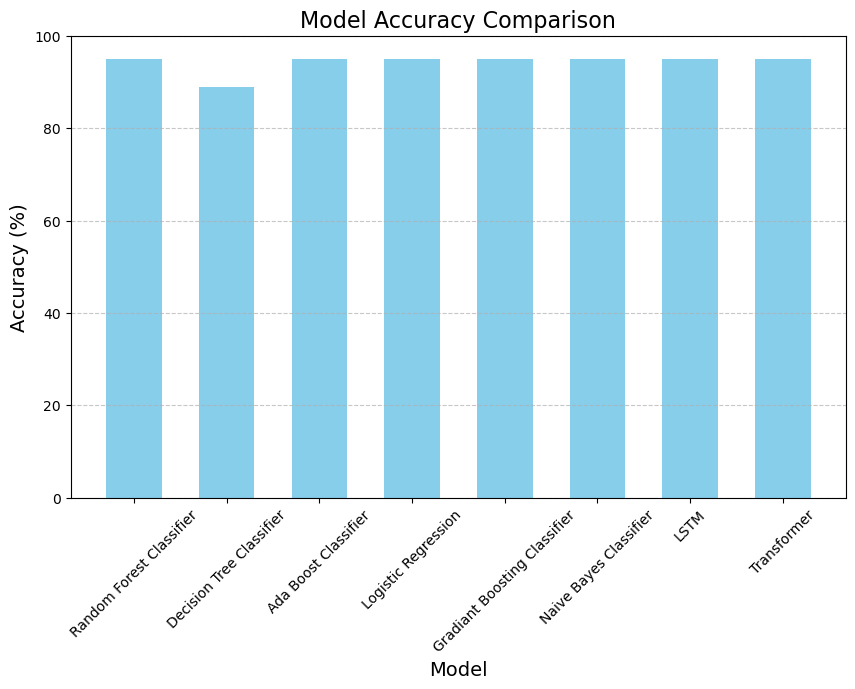

In [26]:
metrics_df = pd.DataFrame(metrics)
plt.figure(figsize=(10, 6))
plt.bar(metrics_df['Model'], metrics_df['Accuracy'], color='skyblue', width=0.6)
plt.title('Model Accuracy Comparison', fontsize=16)
plt.ylabel('Accuracy (%)', fontsize=14)
plt.xlabel('Model', fontsize=14)
plt.xticks(rotation=45)
plt.ylim(0, 100) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()